# Image Augmentation Ablation Study

- **no_aug / basic_aug / CutMix / Mixup** 비교 실험
- 데이터: Stanford Dogs
- Model: ResNet-50

In [1]:
# PyTorch and torchvision
import torch
import torchvision
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split, Dataset
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm   # 학습 상태 확인

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.benchmark = True  # 입력 크기 고정(224)이라 conv 알고리즘 자동 최적화 --> 학습 속도 증가
print(f"Using device: {device}")

Using device: cuda


In [3]:
# 하이퍼파라미터 설정
BATCH_SIZE = 64
EPOCH = 25
LR = 0.001
IMG_SIZE = 224
NUM_CLASSES = 120

## 데이터 준비

In [4]:
dataset_dir = "./data/Images/"

full_dataset = ImageFolder(root=dataset_dir)

total_size = len(full_dataset)
train_size = int(0.583 * total_size)
test_size = total_size - train_size

# split은 한 번만 수행 --> 모든 실험이 동일한 train/test 분할을 공유
ds_train, ds_test = random_split(full_dataset, [train_size, test_size])

ds_info = {
    "num_classes": len(full_dataset.classes),
    "class_names": full_dataset.classes,
}

print("train:", train_size)
print("test:", test_size)
print("num_classes:", ds_info["num_classes"])

train: 11998
test: 8582
num_classes: 120


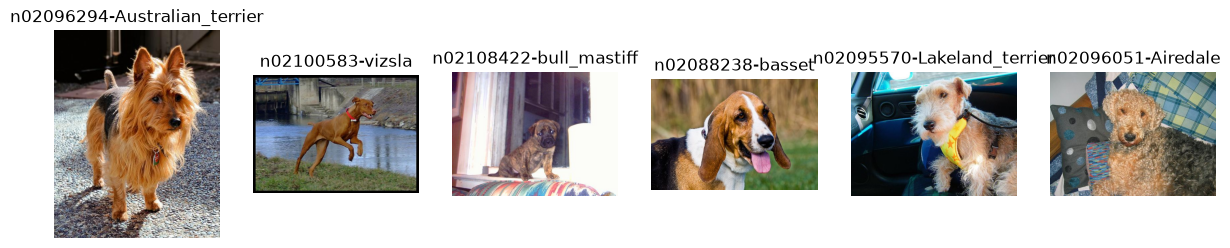

In [5]:
# 원본 데이터셋 시각화
def show_examples(dataset, class_names, num_images=6):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(num_images):
        image, label = dataset[i]
        axes[i].imshow(image)
        axes[i].axis('off')
        axes[i].set_title(class_names[label])
    plt.show()

show_examples(ds_train, ds_info["class_names"])

## 전처리 & 기본 Augmentation

In [6]:
# 공통 전처리 (train/test 모두 적용)
def normalize_and_resize_img():
    return transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ])

In [7]:
# 기본 augmentation: 좌우 반전 + 밝기 조절
def augment():
    return transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2),
    ])

In [8]:
class TransformedSubset(Dataset):
    """random_split이 만든 Subset에 개별 transform을 적용하는 래퍼.

    원본 데이터셋(full_dataset)은 transform 없이 PIL 이미지를 반환하고,
    여기서 split마다 다른 transform을 씌움
    """
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]  # PIL 이미지, 정수 라벨
        if self.transform:
            image = self.transform(image)
        return image, label

In [9]:
def apply_normalize_on_dataset(dataset, is_test=False, batch_size=BATCH_SIZE, with_aug=False):
    transform = normalize_and_resize_img()

    # train + with_aug일 때
    if not is_test and with_aug:
        transform = transforms.Compose([
            *augment().transforms,
            *transform.transforms,
        ])

    ds = TransformedSubset(dataset, transform=transform)

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=not is_test,
        num_workers=0,
        pin_memory=True,
        drop_last=not is_test,   # batch size와 맞지 않으면 마지막 데이터 버림
    )

## CutMix / Mixup

In [10]:
def get_clip_box(image_a, image_b):
    """CutMix에서 삽입할 영역(bounding box) 위치를 결정. image.shape = (C, H, W)"""
    image_size_y = image_a.shape[1]  # Height
    image_size_x = image_a.shape[2]  # Width

    # 박스 중심 좌표
    x = torch.randint(0, image_size_x, (1,)).item()
    y = torch.randint(0, image_size_y, (1,)).item()

    # 박스 크기 (sqrt(1-u) 비율로 면적 결정)
    width = max(1, int(image_size_x * torch.sqrt(1 - torch.rand(1)).item()))
    height = max(1, int(image_size_y * torch.sqrt(1 - torch.rand(1)).item()))

    x_min = max(0, x - width // 2)
    y_min = max(0, y - height // 2)
    x_max = min(image_size_x, x + width // 2 + 1)
    y_max = min(image_size_y, y + height // 2 + 1)

    return x_min, y_min, x_max, y_max

In [11]:
def mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max):
    """배경(image_a)에 image_b의 박스 영역을 삽입해 합침. image.shape = (C, H, W)"""
    
    if isinstance(image_a, np.ndarray):
        image_a = torch.from_numpy(image_a)
    if isinstance(image_b, np.ndarray):
        image_b = torch.from_numpy(image_b)

    top = image_a[:, :y_min, :]
    middle_left = image_a[:, y_min:y_max, :x_min]
    middle_center = image_b[:, y_min:y_max, x_min:x_max]
    middle_right = image_a[:, y_min:y_max, x_max:]
    bottom = image_a[:, y_max:, :]

    middle = torch.cat([middle_left, middle_center, middle_right], dim=2)
    mixed_img = torch.cat([top, middle, bottom], dim=1)
    return mixed_img

In [12]:
def mix_2_labels(image_a, label_a, label_b, x_min, y_min, x_max, y_max, num_classes=NUM_CLASSES):
    """박스 면적 비율에 따라 두 라벨을 혼합"""
    image_size_y = image_a.shape[1]  # Height
    image_size_x = image_a.shape[2]  # Width

    mixed_area = (x_max - x_min) * (y_max - y_min)
    total_area = image_size_x * image_size_y
    ratio = mixed_area / total_area

    label_a = F.one_hot(torch.as_tensor(label_a).long(), num_classes).float()
    label_b = F.one_hot(torch.as_tensor(label_b).long(), num_classes).float()

    mixed_label = (1 - ratio) * label_a + ratio * label_b
    return mixed_label

In [13]:
def cutmix(images, labels, num_classes=NUM_CLASSES):
    """배치 단위 CutMix"""
    bs = images.size(0)
    mixed_imgs, mixed_labels = [], []

    for i in range(bs):
        image_a, label_a = images[i], labels[i]

        j = torch.randint(0, bs, (1,)).item()  # 섞을 다른 샘플 선택
        image_b, label_b = images[j], labels[j]

        x_min, y_min, x_max, y_max = get_clip_box(image_a, image_b)
        mixed_imgs.append(mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max))
        mixed_labels.append(mix_2_labels(image_a, label_a, label_b, x_min, y_min, x_max, y_max, num_classes))

    return torch.stack(mixed_imgs), torch.stack(mixed_labels)

In [14]:
def mixup_2_images(image_a, image_b, label_a, label_b, num_classes=NUM_CLASSES):
    """두 이미지/라벨을 랜덤 비율로 픽셀 단위 혼합"""
    ratio = torch.rand(1).item()  # 0~1 랜덤 비율

    label_a = F.one_hot(torch.as_tensor(label_a).long(), num_classes).float()
    label_b = F.one_hot(torch.as_tensor(label_b).long(), num_classes).float()

    mixed_image = (1 - ratio) * image_a + ratio * image_b
    mixed_label = (1 - ratio) * label_a + ratio * label_b
    return mixed_image, mixed_label

In [15]:
def mixup(images, labels, num_classes=NUM_CLASSES):
    """배치 단위 Mixup"""
    bs = images.size(0)
    mixed_imgs, mixed_labels = [], []

    for i in range(bs):
        image_a, label_a = images[i], labels[i]

        j = torch.randint(0, bs, (1,)).item()
        image_b, label_b = images[j], labels[j]

        mi, ml = mixup_2_images(image_a, image_b, label_a, label_b, num_classes)
        mixed_imgs.append(mi)
        mixed_labels.append(ml)

    return torch.stack(mixed_imgs), torch.stack(mixed_labels)

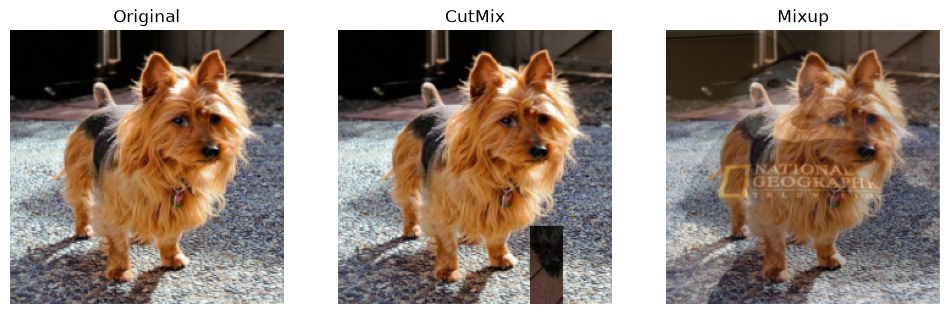

In [16]:
# CutMix / Mixup 적용 결과 시각화 
def denormalize(img):
    """(C,H,W) 정규화 텐서 -> (H,W,C) [0,1] numpy"""
    img = img.cpu().numpy().transpose(1, 2, 0)
    return np.clip(img * 0.5 + 0.5, 0, 1)

demo_loader = apply_normalize_on_dataset(ds_train, is_test=True)  # shuffle/aug 없는 배치
demo_imgs, demo_labels = next(iter(demo_loader))

cut_imgs, _ = cutmix(demo_imgs, demo_labels)
mix_imgs, _ = mixup(demo_imgs, demo_labels)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(denormalize(demo_imgs[0])); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(denormalize(cut_imgs[0]));  axes[1].set_title('CutMix');   axes[1].axis('off')
axes[2].imshow(denormalize(mix_imgs[0]));  axes[2].set_title('Mixup');    axes[2].axis('off')
plt.show()

## 모델 구현

In [17]:
def build_resnet50(num_classes=NUM_CLASSES):
    """ImageNet 사전학습 ResNet-50에 새 분류기만 붙임"""
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

resnet50_no_aug = build_resnet50()   # No Augmentation 학습 모델
resnet50_aug    = build_resnet50()   # Basic Augmentation 학습 모델
resnet50_cutmix = build_resnet50()   # CutMix 학습 모델
resnet50_mixup  = build_resnet50()   # Mixup 학습 모델

## Training

In [18]:
criterion = nn.CrossEntropyLoss()  # 손실함수

In [19]:
def train(model, train_loader, test_loader, epochs):
    """no_aug / basic_aug 용 학습 루프"""
    model.to(device)
    optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9)
    history = {'val_accuracy': []}

    for epoch in range(epochs):
        # ===== Trainining =====
        model.train()
        correct = total = 0
        
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        print(f"Epoch [{epoch+1}/{epochs}], Train Accuracy: {100.*correct/total:.2f}%")

        # ===== Validation =====
        model.eval()
        correct = total = 0
        
        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
                
        val_acc = 100. * correct / total
        history['val_accuracy'].append(val_acc)
        
        print(f"Validation Accuracy: {val_acc:.2f}%")

    return history

In [20]:
def train_mix(model, base_loader, test_loader, epochs, mix_fn):
    """CutMix/Mixup용 학습 루프.

    - base_loader: resize+normalize만 된 배치 (loader_no_aug 재사용)
    - mix_fn: cutmix 또는 mixup
    """
    model.to(device)
    optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9)
    history = {'val_accuracy': []}

    for epoch in range(epochs):
        # ===== Trainining =====
        model.train()
        running_loss = 0.0
        n_batches = 0
        for images, labels in tqdm(base_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            mixed_imgs, mixed_labels = mix_fn(images, labels)  # CPU에서 mix
            mixed_imgs = mixed_imgs.to(device, non_blocking=True)
            mixed_labels = mixed_labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(mixed_imgs)
            loss = criterion(outputs, mixed_labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            n_batches += 1

        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {running_loss/n_batches:.4f}")

        # ===== Validation =====
        model.eval()
        correct = total = 0
        
        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
                
        val_acc = 100. * correct / total
        history['val_accuracy'].append(val_acc)
        
        print(f"Validation Accuracy: {val_acc:.2f}%")

    return history

In [21]:
# 동일한 고정 split을 공유
loader_no_aug = apply_normalize_on_dataset(ds_train, with_aug=False)  # drop_last=True
loader_aug    = apply_normalize_on_dataset(ds_train, with_aug=True)   # drop_last=True
loader_test   = apply_normalize_on_dataset(ds_test,  is_test=True)    # drop_last=False

In [22]:
# No Augmentation
hist_no_aug = train(resnet50_no_aug, loader_no_aug, loader_test, EPOCH)

Epoch 1/25:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch [1/25], Train Accuracy: 36.05%
Validation Accuracy: 66.78%


Epoch 2/25:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch [2/25], Train Accuracy: 74.36%
Validation Accuracy: 79.32%


Epoch 3/25:   0%|          | 0/187 [00:00<?, ?it/s]

...

Epoch [23/25], Train Accuracy: 99.85%
Validation Accuracy: 82.79%


Epoch 24/25:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch [24/25], Train Accuracy: 99.87%
Validation Accuracy: 82.79%


Epoch 25/25:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch [25/25], Train Accuracy: 99.83%
Validation Accuracy: 82.66%


In [23]:
# Basic Augmentation
hist_aug = train(resnet50_aug, loader_aug, loader_test, EPOCH)

Epoch 1/25:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch [1/25], Train Accuracy: 35.79%
Validation Accuracy: 64.55%


Epoch 2/25:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch [2/25], Train Accuracy: 73.68%
Validation Accuracy: 78.77%


Epoch 3/25:   0%|          | 0/187 [00:00<?, ?it/s]

...

Epoch [23/25], Train Accuracy: 99.77%
Validation Accuracy: 83.65%


Epoch 24/25:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch [24/25], Train Accuracy: 99.77%
Validation Accuracy: 83.49%


Epoch 25/25:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch [25/25], Train Accuracy: 99.79%
Validation Accuracy: 83.50%


In [24]:
# CutMix
hist_cutmix = train_mix(resnet50_cutmix, loader_no_aug, loader_test, EPOCH, mix_fn=cutmix)

Epoch 1/25:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch [1/25], Train Loss: 4.4482
Validation Accuracy: 51.14%


Epoch 2/25:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch [2/25], Train Loss: 3.5116
Validation Accuracy: 71.09%


Epoch 3/25:   0%|          | 0/187 [00:00<?, ?it/s]

...

Epoch [23/25], Train Loss: 1.7136
Validation Accuracy: 82.63%


Epoch 24/25:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch [24/25], Train Loss: 1.7074
Validation Accuracy: 82.96%


Epoch 25/25:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch [25/25], Train Loss: 1.6738
Validation Accuracy: 83.07%


In [25]:
# Mixup
hist_mixup = train_mix(resnet50_mixup, loader_no_aug, loader_test, EPOCH, mix_fn=mixup)

Epoch 1/25:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch [1/25], Train Loss: 4.3635
Validation Accuracy: 48.07%


Epoch 2/25:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch [2/25], Train Loss: 3.3035
Validation Accuracy: 70.54%


Epoch 3/25:   0%|          | 0/187 [00:00<?, ?it/s]

...

Epoch [23/25], Train Loss: 1.8772
Validation Accuracy: 82.38%


Epoch 24/25:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch [24/25], Train Loss: 1.8609
Validation Accuracy: 82.67%


Epoch 25/25:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch [25/25], Train Loss: 1.8529
Validation Accuracy: 82.50%


## 성능 비교 분석

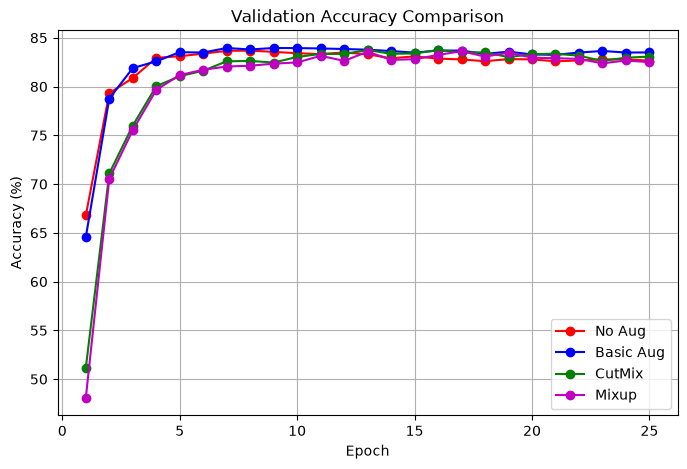

In [26]:
# Validation Accuracy 시각화
epochs_range = range(1, EPOCH + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, hist_no_aug['val_accuracy'], 'r-o', label='No Aug')
plt.plot(epochs_range, hist_aug['val_accuracy'],    'b-o', label='Basic Aug')
plt.plot(epochs_range, hist_cutmix['val_accuracy'], 'g-o', label='CutMix')
plt.plot(epochs_range, hist_mixup['val_accuracy'],  'm-o', label='Mixup')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

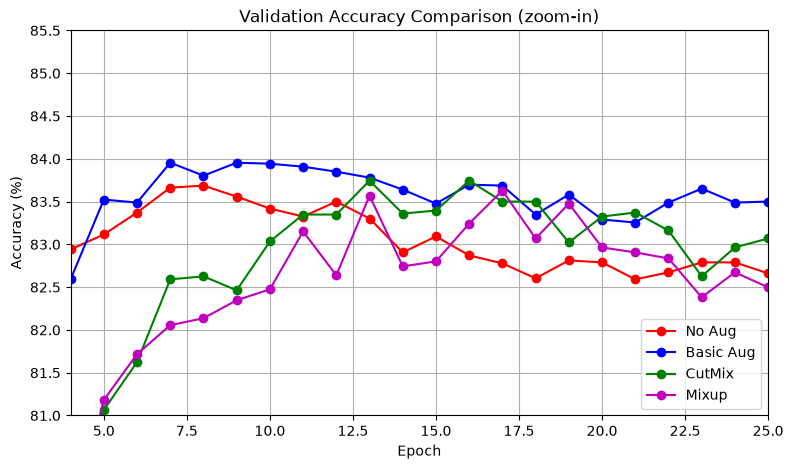

In [30]:
epochs_range = range(1, EPOCH + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_range, hist_no_aug['val_accuracy'], 'r-o', label='No Aug')
plt.plot(epochs_range, hist_aug['val_accuracy'],    'b-o', label='Basic Aug')
plt.plot(epochs_range, hist_cutmix['val_accuracy'], 'g-o', label='CutMix')
plt.plot(epochs_range, hist_mixup['val_accuracy'],  'm-o', label='Mixup')

plt.title('Validation Accuracy Comparison (zoom-in)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')

# ↓↓↓ 핵심: 수렴 구간으로 y축 확대
plt.ylim(81, 85.5)          # 데이터에 맞춰 조정 (예: 82~85 더 좁게도 가능)
plt.xlim(4, EPOCH)          # 초반 급상승 구간 제외 → 후반 차이가 덜 눌림 (선택)
plt.yticks(np.arange(81, 85.6, 0.5))  # y눈금 촘촘하게

plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### 1. 최종 결과

| 기법 | 최종 val (25ep) | 최고 val | 최고 epoch | 최고 이후 하락폭 |
|------|:---:|:---:|:---:|:---:|
| No Aug     | 82.66% | 83.69% | 8  | −1.03%p |
| **Basic Aug** | **83.50%** | **83.95%** | 7  | −0.45%p |
| CutMix     | 83.07% | 83.75% | 13 | −0.68%p |
| Mixup      | 82.50% | 83.63% | 17 | −1.13%p |

- 최고/최종 Validation Accuracy 모두 Basic Augmentation이 1위 (최고 83.95%, 최종 83.50%).
- 4개 기법이 모두 82.5~84% 구간에 몰려 있어 성능 차이는 최대 ~1.5%p로 작다.
---
### 2. Overfitting과 정규화 효과

train–val 격차와 val 곡선의 정점 시점에서 기법별 성격이 뚜렷하게 갈렸다.

- **No Aug**: train accuracy가 epoch 12에 이미 99.8%로 포화되고, val은 epoch 8(83.69%)에서 정점을 찍은 뒤 지속적으로 하락(→82.66%). train 99.8% vs val 82.7%로 격차가 가장 크며, 가장 빠르게 과적합되었다.
- **Basic Aug**: val이 epoch 7 정점 이후에도 83.5% 근처에서 안정적으로 유지되어(하락폭 −0.45%p로 최소) 과적합 억제 효과가 확인되었다.
- **CutMix / Mixup**: val 정점이 각각 epoch 13, 17로 가장 늦게 나타났다. train loss가 25 epoch 내내 단조 감소(CutMix 4.45→1.67, Mixup 4.36→1.85)하는데도 val이 계속 완만히 상승 → 라벨 혼합으로 학습 난이도가 높아 정규화가 가장 강하게 작용했음을 보여준다.

> **정점 epoch 순서: Basic(7) < No Aug(8) ≪ CutMix(13) < Mixup(17)**
> — 정규화가 강할수록 모델이 데이터를 외우기까지 더 오래 걸려 정점이 뒤로 밀린다.
---
### 3. 성능 차이

Stanford Dogs의 견종 클래스는 ImageNet에 이미 상당수 포함되어 있어, ImageNet 사전학습 모델을 사용하면 augmentation 없이도 baseline이 82~84%에 이를 만큼 성능이 높다. 이미 성능 상한에 가까워 augmentation이 정확도를 추가로 높일 여지가 작았다.

즉, 이 task에서 augmentation은 정확도를 높이는 효과는 미미했지만, 과적합을 늦추고 학습의 안정성을 높이는 방향으로 작용했다.

---
### 4. 결론

- **Basic Augmentation (좌우 반전 + 밝기 조절)이 최적이다.** 최고·최종 accuracy가 모두 가장 높고, No Aug 대비 과적합을 눈에 띄게 억제하면서 학습 비용은 거의 늘지 않는다.
- **CutMix / Mixup**은 과적합 저항성은 가장 강했지만, 25 epoch 안에서는 Basic Aug의 절대 성능을 넘지 못했다. 두 기법이 원래 많은 epoch의 긴 스케줄에서 이점이 드러나는 강한 정규화 기법이기 때문이다(특히 Mixup은 정점이 epoch 17로 가장 늦고 최종값도 가장 낮음).

---
### 5. 문제점 및 한계

- **강한 baseline으로 인한 천장 효과**: 사전학습+도메인 중첩으로 기법 간 변별력이 작았다. scratch 학습이나 소량 데이터였다면 augmentation 효과가 더 크게 드러났을 것이다.
- **CutMix/Mixup의 학습 길이 부족**: 25 epoch은 강한 정규화 기법의 이점을 충분히 끌어내기에 짧았다.

---
### 6. 향후 개선 방향

- CutMix/Mixup을 100 epoch 이상으로 확장해 정규화 이점이 실제로 역전되는지 확인
- learning rate scheduler(cosine 등) 적용, `RandomErasing`(Cutout) 등 추가 기법 비교

---
### 7. 회고

**배운점**

- CutMix, Mixup은 두 이미지와 라벨을 섞는 기법이라 한 장씩 처리하는 transform에 넣을 수 없고 학습 루프에서 다른 샘플을 가져와 섞고, 정답도 비율로 나눈 soft label로 바꿔 학습해야 한다.
- `random_split`으로 데이터셋을 분할하면 나눈 subset이 원본 dataset을 공유해 간섭이 생긴다. split마다 다른 transformㅇ르 적용하려면 subset을 감싸 transform만 따로 소유하는 래퍼가 필요하다.

**아쉬운점**

- 한 번 학습을 돌리는 데 시간이 오래 걸려 epoch을 더 크게 주거나 다양한 augmentation을 실험하지 못한 점이 아쉽다.
- train/val loss도 그래프로 시각화하여 정확히 어디에서 과적합이 발생하는지 확인했으면 좋았을 것 같다. 학습을 다시 돌릴 엄두가 나지 않았다...
- Windows 환경에서 `num_workers`를 늘리면 데이터 로더가 멈추는 문제가 생겨 `num_workers=0`으로 학습해 GPU를 제대로 활용하지 못했다. GPU 설정에 대해서도 공부해 봐야겠다.